In [35]:
"""
This is a demo for UNSW 2024T2 COMP9517 Project - TransUnet
Group: WYSIWYG
"""
import os
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from torchsummary import summary
from albumentations.pytorch import ToTensorV2


from TransUnet import TransUnet
from utils import get_loaders, random_show_result, split_subset, MAPPING_INFO
from trainer import train, evaluation

# dataset settings
TRAIN_SPLIT_RATIO = 0.002   # about 12 images for showing training
TEST_SPLIT_RATIO = 0.002   # about 4 images for showing testing
TRAIN_DS = 'sub_train'
TEST_DS = 'sub_test'

# Hyper Params
CLASS_NUM = 19
BATCH_SIZE = 2
NUM_EPOCH = 25
NUM_WORKERS = 2
PIN_MEMORY = True
LOAD_MODEL = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CROPPED_INPUT_SIZE = 512


# model settings
MODEL = TransUnet(
    img_dim=CROPPED_INPUT_SIZE,
    in_channels=3,
    out_channels=128,
    head_num=4,
    mlp_dim=512,
    block_num=4,
    patch_dim=16,
    class_num=CLASS_NUM,
).to(DEVICE)
MODEL_NAME = MODEL.__class__.__name__

LEARNING_RATE = 1e-4
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(MODEL.parameters(), lr=LEARNING_RATE)

AMP_FLAG = False        # if use mixed precision training
if AMP_FLAG:
    scaler = torch.cuda.amp.GradScaler()    # Automatic Mixed Precision

else:
    scaler = None

In [37]:
# model summary, CROPPED_INPUT_SIZE = 512 (same as WildScenes paper)
summary(MODEL, (3, CROPPED_INPUT_SIZE, CROPPED_INPUT_SIZE))    

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 128, 256, 256]          18,816
       BatchNorm2d-2        [-1, 128, 256, 256]             256
              ReLU-3        [-1, 128, 256, 256]               0
            Conv2d-4        [-1, 256, 128, 128]          32,768
       BatchNorm2d-5        [-1, 256, 128, 128]             512
            Conv2d-6        [-1, 256, 256, 256]          32,768
       BatchNorm2d-7        [-1, 256, 256, 256]             512
              ReLU-8        [-1, 256, 256, 256]               0
            Conv2d-9        [-1, 256, 128, 128]         589,824
      BatchNorm2d-10        [-1, 256, 128, 128]             512
             ReLU-11        [-1, 256, 128, 128]               0
           Conv2d-12        [-1, 256, 128, 128]          65,536
      BatchNorm2d-13        [-1, 256, 128, 128]             512
             ReLU-14        [-1, 256, 1

In [39]:
# imgae augmentation
train_transform = A.Compose([
    # Consistency with the original paper
    A.RandomResizedCrop(height=CROPPED_INPUT_SIZE, width=CROPPED_INPUT_SIZE,
                        scale=(0.5, 1.0), ratio=(0.75, 1.33), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2()
])

In [41]:
# Dataset loader
train_loader, test_loader = get_loaders(
    train_dataset_type=TRAIN_DS,
    test_dataset_type=TEST_DS,
    train_transfrom=train_transform,
    test_transform=test_transform,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [ ]:
# use Demo dataset
split_subset('train', TRAIN_SPLIT_RATIO)
split_subset('test', TEST_SPLIT_RATIO)

# Train Demo
train_loss = train(train_loader, MODEL, loss_fn, optimizer, scaler)
_, _ = evaluation(test_loader, MODEL, 1, train_loss)

Testing:  50%|█████████████████████████████████████▌                                     | 2/4 [01:02<01:00, 30.20s/it]

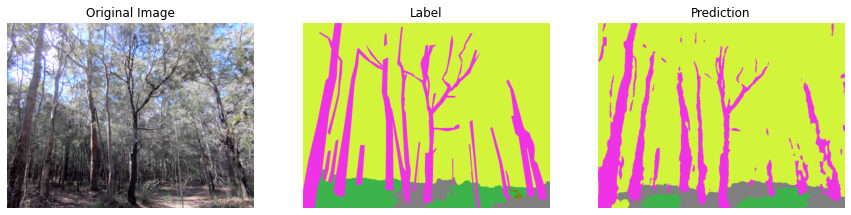

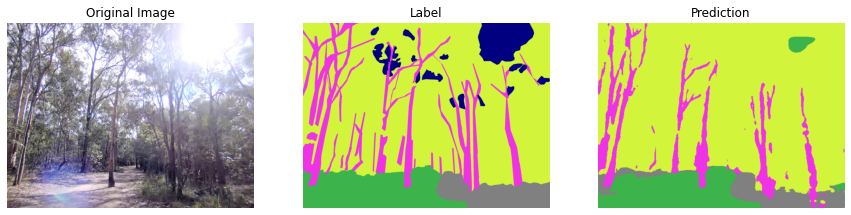

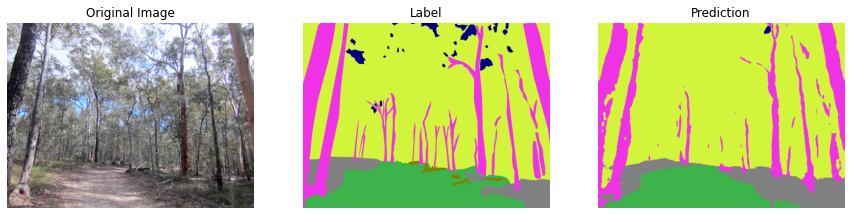

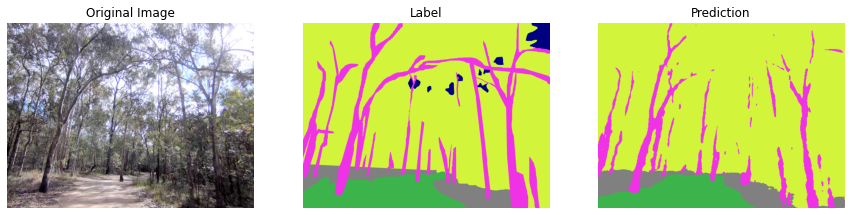

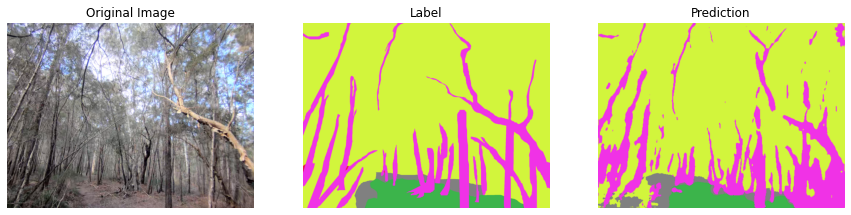

In [31]:
# show segementation results (using best mdoel)
# UNABLE to upload model file (TransUnet_15.pth, 183 MB)
# so DO NOT run this block again ***PLEASE*** !

for i in range(5):
    random_show_result(MODEL, DEVICE, MODEL_NAME, 15)